In [1]:
#Read and print a 3D dicom file. 
#Load a set of DICOM 3D images and do the average, then save the averaged image in the same folder

In [2]:
%matplotlib inline

In [3]:
import os 
import pydicom
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [4]:
# Get the current directory
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(current_dir)

# Change to the parent directory
#os.chdir(parent_dir)

# Get the absolute path of the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))

# Print the parent directory path
print(parent_dir)

#Get the Data directory path 
Data_dir = os.path.join(parent_dir,"Dati", "Dati_1_26_05", "acquisizioni_original_cq_standard_2023-05-29_1549", "Serie separate_STD")
print(Data_dir)

/Users/mariairenetenerani/Desktop/Università/Tesi/Materiale
/Users/mariairenetenerani/Desktop/Università/Tesi/Materiale/Dati/Dati_1_26_05/acquisizioni_original_cq_standard_2023-05-29_1549/Serie separate_STD


<class 'numpy.ndarray'>


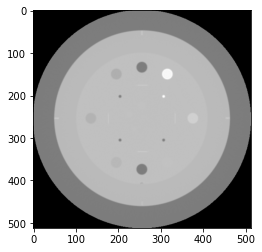

In [5]:
#Open a Dicom image as an example

file_name = os.path.join(Data_dir, "FBP_CQ_1.dcm")
dataset = pydicom.dcmread(file_name)
print(type(dataset.pixel_array))

# Get the pixel array data
pixel_array = dataset.pixel_array

#plot a single slice
plt.imshow(pixel_array[24,:,:], cmap=plt.cm.gray)
plt.show()


Shape of the array of all images: (10, 28, 512, 512)
Shape of average array: (28, 512, 512)


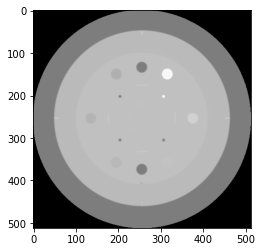

In [6]:
# Get the average image of the ten acquisition

# Specify the path to the folder containing the DICOM files
Data_dir = os.path.join(parent_dir,"Dati", "Dati_1_26_05", "Tentativi","Dati_26_05_divisi_tipologia", "FBP")
folder_path = Data_dir

# Get the list of DICOM files in the folder
file_list = os.listdir(folder_path)

# Sort the file list to ensure consistent order
file_list.sort()

# Create an empty array to store the pixel arrays of all DICOM images
pixel_arrays = []

# Load and store the pixel arrays of each DICOM image
for file_name in file_list[:10]:  # Select the first 10 files
    file_path = os.path.join(folder_path, file_name)
    ds = pydicom.dcmread(file_path)
    pixel_array = ds.pixel_array
    pixel_arrays.append(pixel_array)

# Convert the list of pixel arrays to a NumPy array
pixel_arrays = np.array(pixel_arrays)

print("Shape of the array of all images:", np.shape(pixel_arrays))

# Calculate the average of the pixel arrays
average_array = np.mean(pixel_arrays, axis=0)

# Display the average image or perform further processing as needed
print("Shape of average array:", average_array.shape)

plt.imshow(average_array[24,:,:], cmap=plt.cm.gray)
plt.show()


In [7]:
#Save the new averaged image

# Create a new DICOM dataset
dataset = pydicom.Dataset()

# Set the necessary DICOM attributes for the new dataset
rows, columns, num_slices = average_array.shape
dataset.Rows = rows
dataset.Columns = columns
dataset.NumberOfFrames = num_slices
dataset.PixelData = average_array.tobytes()

# Set other necessary DICOM attributes
dataset.is_little_endian = True
dataset.is_implicit_VR = True

# Set other optional DICOM attributes as needed
dataset.PatientName = "Anonymous"
# Set additional attributes like PatientID, StudyDescription, etc.

# Specify the output DICOM file directory
output_dir = Data_dir

# Specify the desired file name
file_name = "FBP_averaged_image.dcm"

# Combine the output directory and file name to create the output path
output_path = os.path.join(output_dir, file_name)

# Save the dataset as a DICOM file
pydicom.dcmwrite(output_path, dataset)

print("DICOM file saved successfully!")

DICOM file saved successfully!
